# Cell annotation workflow
### Author: Kaili Fan

## Introduction

This notebook demonstrates a semi-manual workflow for cell annotation. The process combines curated lists of differentially expressed genes (DEGs) and marker genes to perform initial (automatic) cell annotation. After this automated step, we review and manually correct the cell annotations as needed. Finally, we save the updated annotations to finalized h5ad files.

In [1]:
import sys
import os

repo_root = os.path.abspath(os.path.join("..")) 
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

It is recommended to start the workflow from the multi-Omic_workflow/cell_annotation directory. This ensures that all relative paths and function imports work as intended. Alternatively, you may use absolute paths if preferred.

In [2]:
os.getcwd()

'/data/fankaili/scripts/multi-Omic_workflow/cell_annotation/notebooks'

In [3]:
os.chdir('../')
os.getcwd()

'/data/fankaili/scripts/multi-Omic_workflow/cell_annotation'

All log outputs are stored in log files within the logs folder.

In [4]:
os.makedirs("test_output/logs", exist_ok=True)

## Config overview

#### YAML File for Storing Input Parameters
All parameters and file paths used in this workflow are stored in config/cell_annotation_config.yaml

Please review this configuration file to ensure that all parameters are correctly specified and as expected before proceeding with the analysis.

In [6]:
from cell_annotation.utils import load_config

config_path = "config/cell_annotation_config.yaml"
config = load_config(config_path)
import yaml
print(yaml.dump(config, default_flow_style=False))

annotation:
  marker_gene_file: /data/fankaili/scripts/multi-Omic_workflow/RNA_QC/test_data/test_marker_gene.xlsx
  sheet_name: test
params:
  suffix: Muscle_Quadriceps
  tissue: Muscle - Quadriceps
paths:
  output_figures_dir: /data/fankaili/scripts/multi-Omic_workflow/RNA_QC/test_output/rna_figures/
  output_h5ad_dir: /data/fankaili/scripts/multi-Omic_workflow/RNA_QC/test_output/rna_h5ad/
  sample_metadata: /data/fankaili/scripts/multi-Omic_workflow/ATAC_QC/test_data/test_metatable.txt
  workdir: /data/fankaili/scripts/multi-Omic_workflow/RNA_QC/test_output/



#### Table for sample information
All sample information is stored in the metatable, which is used throughout all sections of the workflow. You may use a comprehensive metatable containing all of your data; however, this workflow will process samples per designated tissue.

Please ensure your metatable follows the required format and includes all necessary sample data. Below is an example of how this table should look:

In [7]:
import pandas as pd

sample_metadata = pd.read_csv('../ATAC_QC/test_data/test_metatable.txt', sep='\t', header=None)

sample_metadata.head()

,0,1,2,3,4,5,6
0,DGTEX008-2BO-01-SM-OJX6G-EXP01-GEX-01,DGTEX008-2BO-01-SM-OJX6G-EXP01-ATAC-01,Human,DGTEX008,Toddler,M,Muscle - Quadriceps
1,DGTEX027-2BO-01-SM-OJX6J-EXP01-GEX-02,DGTEX027-2BO-01-SM-OJX6J-EXP01-ATAC-02,Human,DGTEX027,Pre-adult,M,Muscle - Quadriceps


#### Table for marker genes


In [8]:
import pandas as pd

marker_gene_list = pd.read_excel('test_data/test_marker_gene.xlsx', sheet_name='test', engine='openpyxl')

marker_gene_list.head()

,Gene,Cell Type
0,AC098829.1,Adipocyte
1,ACACB,Adipocyte
2,ACAD10,Adipocyte
3,ACSL1,Adipocyte
4,ACSL1,Adipocyte


## Step 1 - Automatic cell annotation


In [53]:
!python scripts/annotate_cells.py config/cell_annotation_config.yaml

# Here, we are running the script to display logs directly in the notebook.
# For best practice, you can use the command below to save all logs to a file for future reference:
#!python scripts/annotate_cells.py config/cell_annotation_config.yaml > test_output/logs/annotate_cells.log 2>&1

[INFO] Annotating tissue: Muscle - Quadriceps
[INFO] Muscle - Quadriceps: 4364 cells, 32506 genes; 48 valid marker sets
[INFO] Calculating DEGs
[Info] Saved top DEGs to /data/fankaili/scripts/multi-Omic_workflow/cell_annotation/test_output/Muscle_Quadriceps/top_genes_per_cluster.txt
[INFO] Generate dotplot with marker genes...
[INFO] Running scType...
categories: Adipocyte, Capillary endothelial cell, Fibroblast, etc.
var_group_labels: 0, 1, 2, etc.
[INFO] Save files and figures...
[INFO] Completed annotation step for Muscle - Quadriceps.


## Step 2 - Manual cell annotation
Manual cell annotation requires some process based on your dataset. Here I just provide some quick and common ways you might want to use.

### 2-1 load data

In [54]:
import anndata as ad
import scanpy as sc

adata = sc.read_h5ad('/data/fankaili/scripts/multi-Omic_workflow/cell_annotation/test_output/Muscle_Quadriceps/Muscle_Quadriceps_GEX.filtered.processes.autoAnnotated.h5ad')
adata

AnnData object with n_obs × n_vars = 4364 × 32506
    obs: 'pct_exon_reads', 'donorID', 'cellbarcode', 'tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log10_n_genes_by_counts', 'log10_total_counts', 'MALAT1_CPM', 'log10_MALAT1_CPM', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_probabilities', 'leiden_before_harmony', 'leiden_res_0.1', 'leiden_res_0.5', 'leiden_res_1.0', 'leiden', 'sctype_annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dendrogram_leiden', 'dendrogram_sctype_annotation', 'donorID_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_res_0.1',

### 2-2 if you need to sub-cluster any clusters

In [55]:
cluster = '1' # here I just use as example to show the steps

In [56]:
adata_cluster = adata[adata.obs['leiden']==cluster,:].copy()
adata_cluster

AnnData object with n_obs × n_vars = 1744 × 32506
    obs: 'pct_exon_reads', 'donorID', 'cellbarcode', 'tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log10_n_genes_by_counts', 'log10_total_counts', 'MALAT1_CPM', 'log10_MALAT1_CPM', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_probabilities', 'leiden_before_harmony', 'leiden_res_0.1', 'leiden_res_0.5', 'leiden_res_1.0', 'leiden', 'sctype_annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dendrogram_leiden', 'dendrogram_sctype_annotation', 'donorID_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_res_0.1',

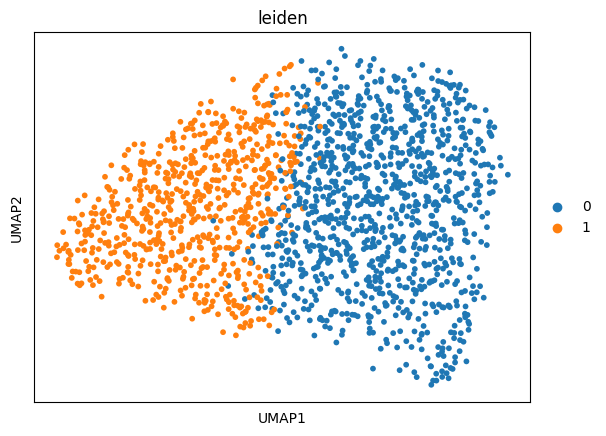

In [57]:
sc.pp.neighbors(adata_cluster)
sc.tl.leiden(adata_cluster, resolution=0.3, flavor="igraph") # change the res here to get the desire subclusters
sc.tl.umap(adata_cluster)
sc.pl.umap(adata_cluster, color=["leiden"])

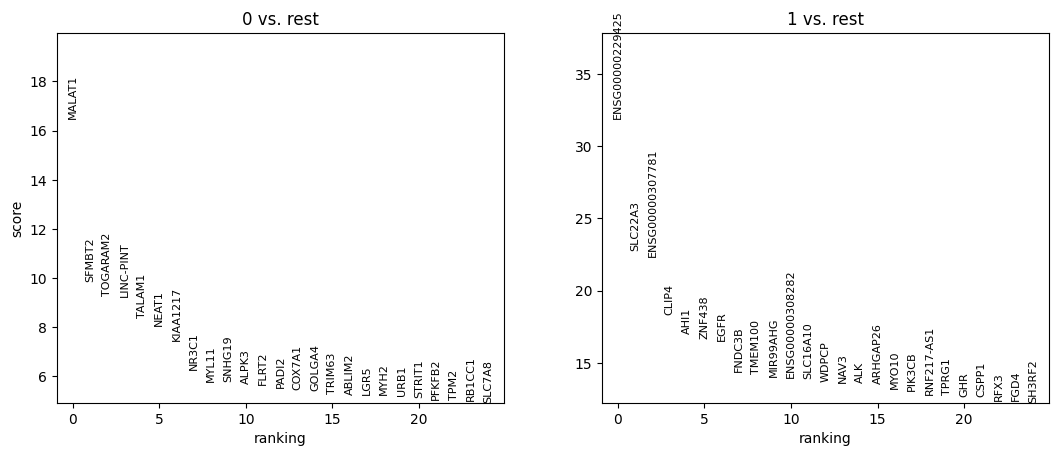

In [58]:
#check if the subclusters are separating
sc.tl.rank_genes_groups(adata_cluster, groupby="leiden", method="t-test")
sc.pl.rank_genes_groups(adata_cluster, n_genes=25, sharey=False)

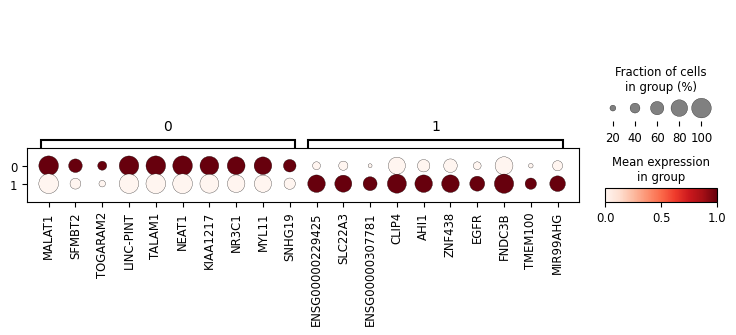

In [59]:
del adata_cluster.uns['dendrogram_leiden']
sc.pl.rank_genes_groups_dotplot(adata_cluster, groupby="leiden", standard_scale="var", n_genes=10)

In [60]:
adata_cluster.obs['leiden'].unique()

['0', '1']
Categories (2, object): ['0', '1']

In [61]:
# if you feel good, add the new leiden back to your adata
adata.obs['leiden_new'] = adata.obs['leiden']

for subcluster in adata_cluster.obs['leiden'].unique(): 
  adata_tmp = adata_cluster[adata_cluster.obs['leiden']==str(subcluster),:]
  cellID = adata_tmp.obs_names
  adata.obs['leiden_new'] = adata.obs['leiden_new'].cat.add_categories([f'{cluster}_{subcluster}'])
  adata.obs.loc[cellID,'leiden_new'] = f'{cluster}_{subcluster}'

adata = adata[~adata.obs['leiden_new'].isin([cluster]), :].copy()
adata.obs['leiden_new'].value_counts()

leiden_new
0      1288
1_0    1074
1_1     670
3       572
2       255
4       144
6       100
5        73
9        66
7        63
10       34
8        25
Name: count, dtype: int64

### 2-3 you can check the top DEGs among all clusters

In [62]:
sc.tl.rank_genes_groups(adata, groupby="leiden_new", method="t-test")

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

# Print top genes per cluster
for group in groups:
    print(f"Top DEGs for cluster {group}:")
    genes = result['names'][group][:20]  # top gene names
    print(genes)
    print()

Top DEGs for cluster 0:
['ATP2A2' 'TNNC1' 'TRDN' 'TNNT1' 'MYL2' 'ARPP21' 'TPM3' 'PAM' 'TOGARAM2'
 'NEB' 'HDAC4' 'RIF1' 'WIPF3' 'ADGRA3' 'CPED1' 'DMD' 'RALGAPA2' 'CKMT2'
 'PFKFB2' 'ESRRG']

Top DEGs for cluster 2:
['EBF1' 'COL6A3' 'LAMA2' 'DLC1' 'DCN' 'RBMS3' 'COL3A1' 'PLXDC2' 'COL1A2'
 'COL5A2' 'NEGR1' 'NFIB' 'NOVA1' 'ABCA8' 'TSHZ2' 'BICC1' 'FBN1' 'CBLB'
 'ARHGAP24' 'LAMC1']

Top DEGs for cluster 3:
['TRDN' 'TNNT3' 'PALLD' 'MEF2C' 'EMC10' 'TTN' 'NEB' 'MYREM' 'CDH13'
 'ATP2A1' 'LDB3' 'SGCD' 'NR4A3' 'MYOM2' 'MYL1' 'MYHAS' 'ACTA1' 'CACNA2D1'
 'MYBPC2' 'TPM1']

Top DEGs for cluster 4:
['TCF4' 'ABLIM1' 'MAGI1' 'B2M' 'DOCK9' 'PECAM1' 'PLEKHG1' 'UTRN' 'MYH9'
 'MCTP1' 'ELMO1' 'PICALM' 'PITPNC1' 'NFIB' 'LRMDA' 'SPTBN1' 'LDB2' 'AFDN'
 'ADAMTS9' 'ARHGAP29']

Top DEGs for cluster 5:
['DLC1' 'RBMS3' 'PDGFRB' 'IGFBP7' 'CALD1' 'PRKG1' 'RBPMS' 'ACTA2' 'EBF1'
 'PDE3A' 'SOX5' 'EPS8' 'COL4A1' 'INPP4B' 'COL4A2' 'NR2F2-AS1' 'CPE'
 'CACNA1C' 'FRMD3' 'RNF152']

Top DEGs for cluster 6:
['LRMDA' 'FCHSD2' 'GRK3

### 2-4 generate new dotplots use new clusters and final marker genes

In [64]:
import pandas as pd

annotation_table = "/data/fankaili/scripts/multi-Omic_workflow/cell_annotation/test_data/Muscle_Quadriceps_GEX.autoAnnotation.xlsx"

df1 = pd.read_excel(annotation_table, sheet_name="Annotation", engine='openpyxl')
annotation_dic = {str(leiden): fine_annotation for leiden, fine_annotation in zip(df1['leiden'], df1['Fine_annotation'])}
broad_annotation_dic = {str(leiden): fine_annotation for leiden, fine_annotation in zip(df1['leiden'], df1['Broad_annotation'])}

df2 = pd.read_excel(annotation_table, sheet_name="Final_Markers", engine='openpyxl')
final_marker_gene_list = df2.groupby("Cell Type")["Gene"].apply(list).to_dict()



In [65]:
sc.pl.dotplot(adata, final_marker_gene_list, groupby="leiden", standard_scale="var")

In [66]:
adata.obs['manual_fine_annotation'] = [annotation_dic[leiden] for leiden in adata.obs['leiden']]
adata.obs['manual_fine_annotation0'] = [str(leiden)+"_"+annotation_dic[leiden] for leiden in adata.obs['leiden']]

adata.obs['manual_broad_annotation'] = [broad_annotation_dic[leiden] for leiden in adata.obs['leiden']]
adata.obs['manual_broad_annotation0'] = [str(leiden)+"_"+broad_annotation_dic[leiden] for leiden in adata.obs['leiden']]



In [67]:
sc.pl.dotplot(adata, final_marker_gene_list, groupby="manual_fine_annotation0", standard_scale="var")

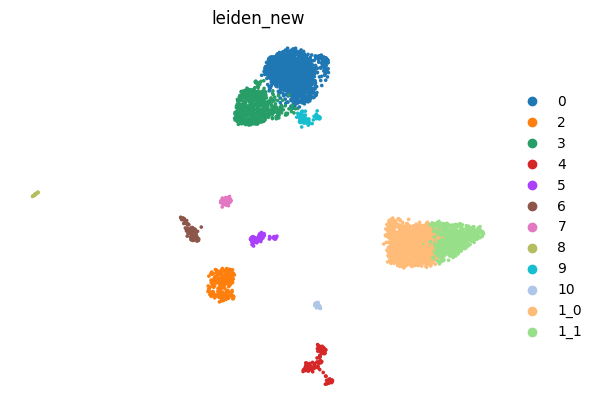

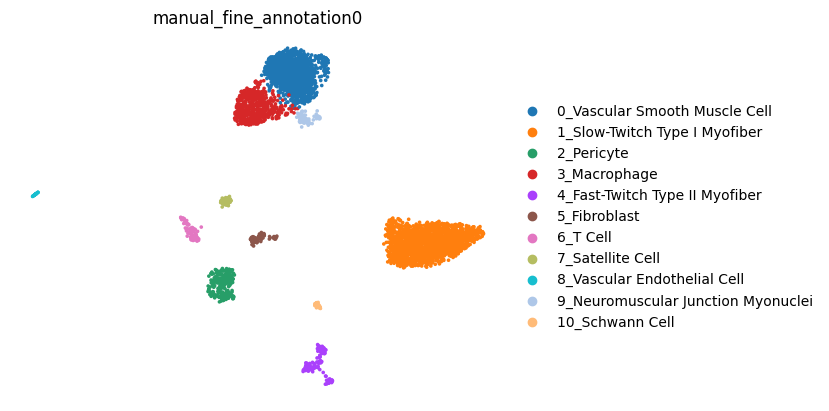

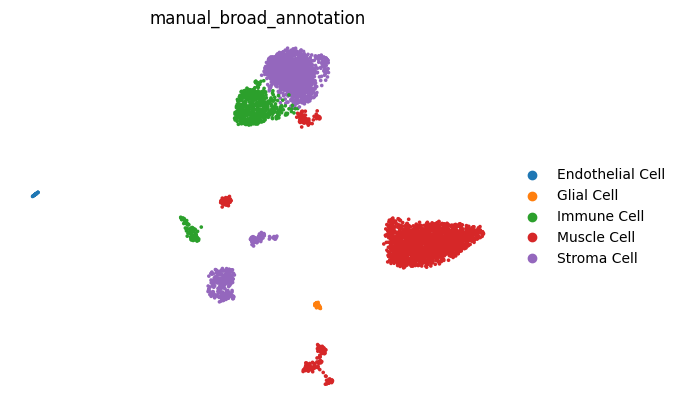

In [68]:
sc.pl.umap(adata, color=['leiden_new'], frameon = False)
sc.pl.umap(adata, color=['manual_fine_annotation0'], frameon = False)
sc.pl.umap(adata, color=['manual_broad_annotation'], frameon = False)

### 2-5 save changes to h5ad files

In [69]:
adata.write_h5ad('/data/fankaili/scripts/multi-Omic_workflow/cell_annotation/test_output/Muscle_Quadriceps/Muscle_Quadriceps_GEX.filtered.processes.autoAnnotated.updated.h5ad')

## Step 3 - Generate final h5ad file

In [76]:
!python scripts/generate_final_h5ad.py config/cell_annotation_config.yaml 'manual_broad_annotation' 'manual_broad_annotation' 'sctype_annotation'

# Here, we are running the script to display logs directly in the notebook.
# For best practice, you can use the command below to save all logs to a file for future reference:
#!python scripts/generate_final_h5ad.py config/cell_annotation_config.yaml 'manual_broad_annotation' 'manual_broad_annotation' 'sctype_annotation' > test_output/logs/generate_final_h5ad.log 2>&1


========== Final annotation for tissue: Muscle - Quadriceps ==========
[INFO] loading adata from /data/fankaili/scripts/multi-Omic_workflow/cell_annotation/test_output/Muscle_Quadriceps/Muscle_Quadriceps_GEX.filtered.processes.autoAnnotated.updated.h5ad
[ERROR] Final h5ad generation failed for Muscle - Quadriceps: "['cellannotation', 'cellannotation_color'] not in index"


In [71]:
adata

AnnData object with n_obs × n_vars = 4364 × 32506
    obs: 'pct_exon_reads', 'donorID', 'cellbarcode', 'tissue', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log10_n_genes_by_counts', 'log10_total_counts', 'MALAT1_CPM', 'log10_MALAT1_CPM', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_probabilities', 'leiden_before_harmony', 'leiden_res_0.1', 'leiden_res_0.5', 'leiden_res_1.0', 'leiden', 'sctype_annotation', 'leiden_new', 'manual_fine_annotation', 'manual_fine_annotation0', 'manual_broad_annotation', 'manual_broad_annotation0'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 